In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX



In [2]:
import pandas as pd

df = pd.read_csv("../data/processed/superstore_features.csv")
df["Order Date"] = pd.to_datetime(df["Order Date"])

In [ ]:
print(df["Order Date"].min())
print(df["Order Date"].max())

2014-01-03 00:00:00
2017-12-30 00:00:00


In [57]:
#Create Monthly Sales Time Series
monthly_sales = (
    df.groupby(pd.Grouper(key="Order Date", freq="ME"))["Sales"]
    .sum()
    .reset_index()
)

monthly_sales.head()

,Order Date,Sales
0,2014-01-31,14236.895
1,2014-02-28,4519.892
2,2014-03-31,55691.009
3,2014-04-30,28295.345
4,2014-05-31,23648.287


In [22]:
monthly_sales.mean()

Order Date    2016-01-14 21:30:00
Sales                47858.351256
dtype: object

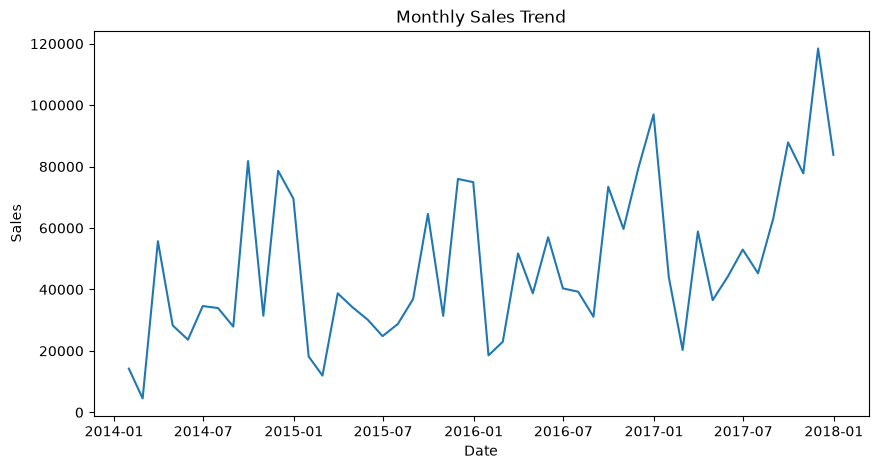

In [58]:
#Visualize Sales Trend
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(monthly_sales["Order Date"], monthly_sales["Sales"])
plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

In [59]:
#preparing series
ts = monthly_sales.set_index("Order Date")

ts.head()

,Sales
Order Date,
2014-01-31,14236.895
2014-02-28,4519.892
2014-03-31,55691.009
2014-04-30,28295.345
2014-05-31,23648.287


In [60]:
#Train-test split
train = ts[:-6]
test = ts[-6:]

print(train.shape)
print(test.shape)

(42, 1)
(6, 1)


In [85]:
#Building SARIMA model
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(
    train["Sales"],
    order=(2,1,2),
    seasonal_order=(1,1,1,12)
)

results = model.fit()

c:\Users\HP\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\HP\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\HP\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


In [86]:
#Forecasting Test Period
forecast = results.forecast(steps=len(test))

forecast

2017-07-31     54401.674177
2017-08-31     47598.889467
2017-09-30     86885.878582
2017-10-31     65628.551962
2017-11-30     92282.981880
2017-12-31    101881.268940
Freq: ME, Name: predicted_mean, dtype: float64

In [87]:
#Evaluate Accuracy
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(test["Sales"], forecast)

print("MAE:", mae)

MAE: 13667.532437523332


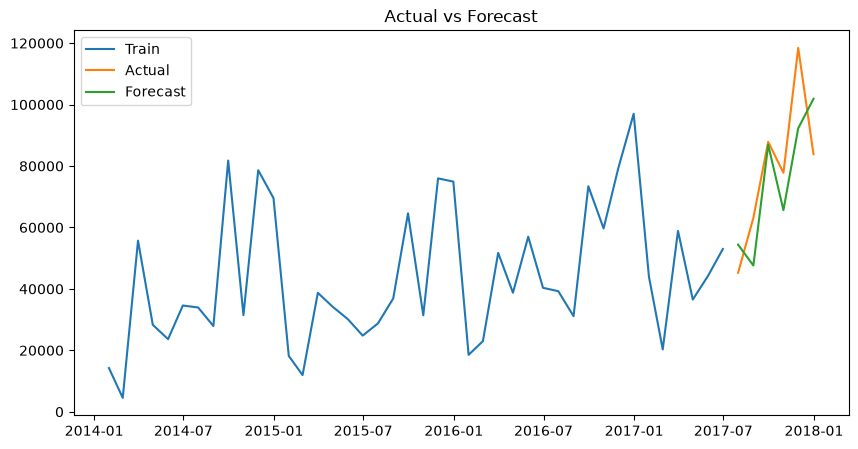

In [88]:
#plotting ACTUAL vs FORECAST
plt.figure(figsize=(10,5))

plt.plot(train.index, train["Sales"], label="Train")
plt.plot(test.index, test["Sales"], label="Actual")
plt.plot(test.index, forecast, label="Forecast")

plt.legend()
plt.title("Actual vs Forecast")
plt.show()

In [89]:
#Forecasting future months
future_forecast = results.forecast(steps=6)

future_forecast

2017-07-31     54401.674177
2017-08-31     47598.889467
2017-09-30     86885.878582
2017-10-31     65628.551962
2017-11-30     92282.981880
2017-12-31    101881.268940
Freq: ME, Name: predicted_mean, dtype: float64

In [90]:
#saving the forecast data
forecast_df = future_forecast.reset_index()
forecast_df.columns = ["Date", "Forecast Sales"]

forecast_df.to_csv(
    "../data/processed/sales_forecast.csv",
    index=False
)